In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [2]:
import pandas as pd

file_path = r"C:\Users\chait\Downloads\beer-manufacturers-microbrewers-brands.xlsx"
df = pd.read_excel(file_path)

print(df.shape)
print(df.columns.tolist())
df.head()


(1604, 3)
['Manufacturer Type (Type de fabricant)', 'Manufacturer Name (Nom du fabricant)', "Manufacturer's Brand (Marque du fabricant)"]


,Manufacturer Type (Type de fabricant),Manufacturer Name (Nom du fabricant),Manufacturer's Brand (Marque du fabricant)
0,Beer Manufacturer,9664483 Canada Inc. o/a Goose Island Brewing C...,NaN
1,Beer Manufacturer,Amsterdam Brewing Co. Limited o/a Amsterdam Br...,Amsterdam Big Wheel
2,Beer Manufacturer,Amsterdam Brewing Co. Limited o/a Amsterdam Br...,Amsterdam Blonde Beer
3,Beer Manufacturer,Amsterdam Brewing Co. Limited o/a Amsterdam Br...,Amsterdam Frambois
4,Beer Manufacturer,Amsterdam Brewing Co. Limited o/a Amsterdam Br...,Amsterdam Natural Blonde Lager


In [3]:
# ---- IMPORT LIBRARIES ----
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- LOAD DATA ----
file_path = r"C:\Users\chait\Downloads\beer-manufacturers-microbrewers-brands.xlsx"  # Adjust path
df = pd.read_excel(file_path)

# ---- PREVIEW ----
print(df.shape)
print(df.columns.tolist())
df.head()


(1604, 3)
['Manufacturer Type (Type de fabricant)', 'Manufacturer Name (Nom du fabricant)', "Manufacturer's Brand (Marque du fabricant)"]


,Manufacturer Type (Type de fabricant),Manufacturer Name (Nom du fabricant),Manufacturer's Brand (Marque du fabricant)
0,Beer Manufacturer,9664483 Canada Inc. o/a Goose Island Brewing C...,NaN
1,Beer Manufacturer,Amsterdam Brewing Co. Limited o/a Amsterdam Br...,Amsterdam Big Wheel
2,Beer Manufacturer,Amsterdam Brewing Co. Limited o/a Amsterdam Br...,Amsterdam Blonde Beer
3,Beer Manufacturer,Amsterdam Brewing Co. Limited o/a Amsterdam Br...,Amsterdam Frambois
4,Beer Manufacturer,Amsterdam Brewing Co. Limited o/a Amsterdam Br...,Amsterdam Natural Blonde Lager


Top 10 Beer Manufacturers in Ontario by Number of Brands - Show which manufacturers produce the greatest variety of beer brands.

C:\Users\chait\AppData\Local\Temp\ipykernel_23164\837080792.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=brand_counts, x='Manufacturer_Name', y='Number_of_Brands', palette='crest')


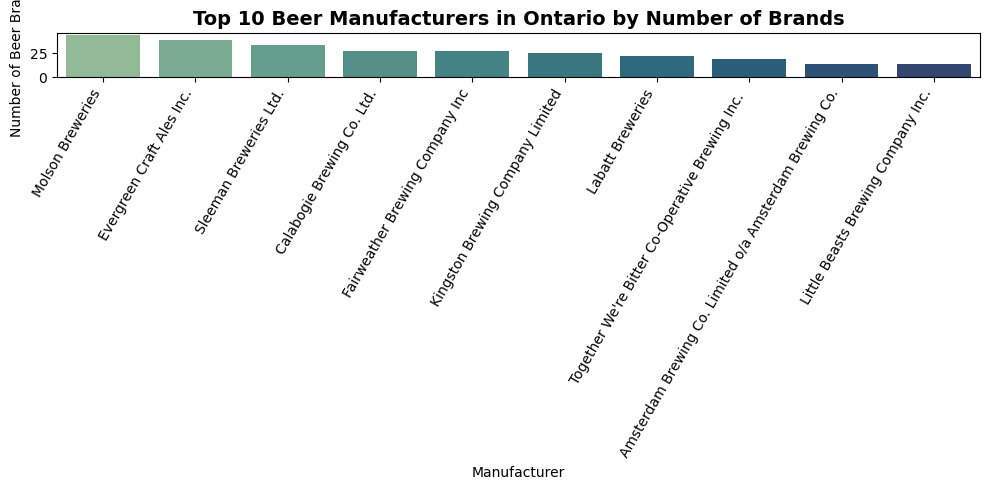

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your Excel data
file_path = r"C:\Users\chait\Downloads\beer-manufacturers-microbrewers-brands.xlsx"
df = pd.read_excel(file_path)

# Clean column names for easy access
df.columns = ['Manufacturer_Type', 'Manufacturer_Name', 'Brand_Name']

# Count brands per manufacturer
brand_counts = df['Manufacturer_Name'].value_counts().head(10).reset_index()
brand_counts.columns = ['Manufacturer_Name', 'Number_of_Brands']

# Plot the top 10
plt.figure(figsize=(10, 5))
sns.barplot(data=brand_counts, x='Manufacturer_Name', y='Number_of_Brands', palette='crest')
plt.title('Top 10 Beer Manufacturers in Ontario by Number of Brands', fontsize=14, fontweight='bold')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Beer Brands')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


Proportion of different beer categories

         Category  Count  Percent
10  Unknown/Other    687     42.8
0             Ale    397     24.8
3           Lager    135      8.4
2             IPA    131      8.2
9           Stout     81      5.0
5         Pilsner     38      2.4
11          Wheat     38      2.4
7          Saison     34      2.1
6          Porter     31      1.9
8            Sour     27      1.7
4        Non-Beer      4      0.2
1           Cider      1      0.1


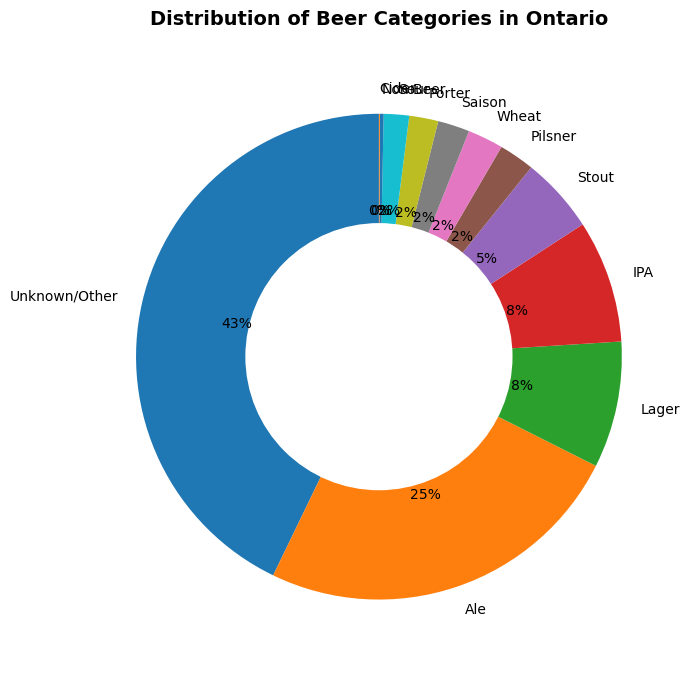

Saved summary to: exports\beer_categories_summary.csv


In [5]:
# --- Visualize the proportion of beer categories (Ale, Lager, Stout, etc.) ---

import re
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load data
file_path = r"C:\Users\chait\Downloads\beer-manufacturers-microbrewers-brands.xlsx"  # <- change if needed
df = pd.read_excel(file_path)  # requires 'openpyxl' installed

# 2) Standardize column names from your sample
df = df.rename(columns={
    'Manufacturer Type (Type de fabricant)': 'Manufacturer_Type',
    'Manufacturer Name (Nom du fabricant)': 'Manufacturer_Name',
    "Manufacturer's Brand (Marque du fabricant)": 'Brand_Name'
})

# 3) Keyword rules to infer categories from Brand_Name (expand if you want)
category_rules = {
    'Ale':       r'\b(ale|pale ale|amber ale|blonde ale|golden ale|cream ale|brown ale|red ale|scotch ale|bitter|esb)\b',
    'IPA':       r'\b(ipa|india pale ale|double ipa|dip a|neipa|session ipa|black ipa)\b',
    'Lager':     r'\b(lager|vienna|marzen|bock|helles|keller|dortmunder)\b',
    'Pilsner':   r'\b(pils|pilsner)\b',
    'Stout':     r'\b(stout|imperial stout)\b',
    'Porter':    r'\b(porter|baltic porter)\b',
    'Wheat':     r'\b(hefe|weiss|weizen|wheat|wit|witbier)\b',
    'Sour':      r'\b(sour|gose|lambic|berliner)\b',
    'Saison':    r'\b(saison|farmhouse)\b',
    'Cider':     r'\b(cider|cidre)\b',
    'Non-Beer':  r'\b(hard seltzer|seltzer|cooler|radler)\b'
}
compiled = {k: re.compile(v, flags=re.IGNORECASE) for k, v in category_rules.items()}

def infer_category(name: str) -> str:
    if not isinstance(name, str) or not name.strip():
        return 'Unknown/Other'
    for cat, pat in compiled.items():
        if pat.search(name):
            return cat
    # fallback heuristic: if a common style word appears, guess broadly
    if re.search(r'\b(ale|lager|stout|porter|pils|pilsner|wheat|weiss|weizen|saison)\b', name, flags=re.IGNORECASE):
        return 'Unknown/BeerStyle'
    return 'Unknown/Other'

# 4) Apply and summarize
df['Category'] = df['Brand_Name'].apply(infer_category)

summary = (df.groupby('Category', as_index=False)
             .size()
             .rename(columns={'size': 'Count'})
             .sort_values('Count', ascending=False))

total = summary['Count'].sum()
summary['Percent'] = (summary['Count'] / total * 100).round(1)

print(summary)

# 5) Plot donut (pie with a hole)
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    summary['Count'],
    labels=summary['Category'],
    autopct='%1.0f%%',
    startangle=90
)

# make it a donut
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
fig.gca().add_artist(centre_circle)

ax.set_title('Distribution of Beer Categories in Ontario', fontsize=14, fontweight='bold')
ax.axis('equal')  # equal aspect ratio = perfect circle
plt.tight_layout()
plt.show()

# 6) Save tidy CSV for Excel/Tableau
os.makedirs("exports", exist_ok=True)
out_csv = os.path.join("exports", "beer_categories_summary.csv")
summary.to_csv(out_csv, index=False, encoding='utf-8')
print(f"Saved summary to: {out_csv}")


Proportion of different beer categories

In [6]:
df['Manufacturer_Type'].value_counts().to_csv("beer_type_distribution.csv")
